# Modeling Hypergraphs of MEDLINE Journals

## Model

* Let $G=(V,E)$ be a hypergraph, where $E$ is the collection of hyperedges.
* Let $H$ be the collection of admissible combinations of nodes, (e.g., if we only consider hyperedges of size less than 10). 
* $G$ is modeled as a collection of random variables ${X_h: h\in H}$.
* $X_h\sim Poisson(\lambda_h)$.
* The mean $\lambda_h$ depends on the (latent) features of nodes in $h$: $$\lambda_h=\sum_k\prod_{i\in h}r_i\theta_{ik},$$ where $\theta_{ik}$ is the percentage of node $i$ in block $k$  ($\sum_{k}\theta_{ik}=1$), and $r_i$ corresponds to the popularity of node $i$.
* Assume $X_h$'s are independent of each other given $\theta=(\theta_i)$ and $r=(r_i)$.
* The distribution of $G$ is given by $$p(G|\theta)=\prod_{h\in H} p(x_h|\theta)$$.
* Estimation: Use stochastic gradient descent to estimate $\theta$ and $r$
    * Let $\theta_{ij}=\theta_{ij}r_i$, so that we only need to deal with one set of variables $\theta$.

## Workbench

In [1]:
import time
import pandas as pd
import scipy.sparse as ssp
import numpy as np
from multiprocessing import Pool, cpu_count
from scipy.stats import dirichlet
from collections import Counter
from datetime import datetime
import random
from collections import defaultdict
from scipy.optimize import minimize
from itertools import zip_longest
from numba import guvectorize,vectorize
from numba import int64,float64,int32
from numba import cuda
import math
import pickle as pickle
from scipy.stats import pearsonr
from sklearn.metrics import precision_recall_curve
from functools import partial

In [2]:
%matplotlib inline
import pylab as plt
import seaborn as sns

In [3]:
class Stopwatch:
    start_time=None
    def go(self,msg=''):
        if msg:
            print(msg, flush=True)
        self.start_time=time.time()
    def stop(self,msg=''):
        if msg:
            print("{}: {} seconds".format(msg,time.time()-self.start_time), flush=True)
        else:
            print("Elapsed time: {} seconds".format(time.time()-self.start_time), flush=True)
    def check(self):
        return time.time()-self.start_time

tic=Stopwatch()

## Load data

In [4]:
def load_date(filename):
    tic=Stopwatch()
    print("Loading paper dates %s from disk..." % filename),
    tic.go()
    pkl_file = open(filename, 'rb')
    A=pickle.load(pkl_file,encoding='latin1')
    pkl_file.close()
    tic.stop()
    return A

def load_hypergraph(filename):
    tic=Stopwatch()
    print("Loading file %s from disk..." % filename),
    tic.go()
    pkl_file = open(filename, 'rb')
    (row,col) = pickle.load(pkl_file,encoding='latin1')
    print(len(row), len(col))
    pkl_file.close()
    A=ssp.coo_matrix((np.ones(len(row),dtype=np.int8),(row,col)),shape=(19916562, max(col)+1),dtype=np.int8)
    tic.stop()
    return A, row, col

In [6]:
tic=Stopwatch()
data_path = '/home/ymwan/Sci4Sci/Aarav/hyper-novelty-main/hyper-novelty-main/Data'
G, row, col = load_hypergraph(f'{data_path}/journals.pkl')
paper_dates=load_date(f'{data_path}/paper_dates.pkl')

Loading file /home/ymwan/Sci4Sci/Aarav/hyper-novelty-main/hyper-novelty-main/Data/journals.pkl from disk...
183054278 183054278
Elapsed time: 28.48678708076477 seconds
Loading paper dates /home/ymwan/Sci4Sci/Aarav/hyper-novelty-main/hyper-novelty-main/Data/paper_dates.pkl from disk...
Elapsed time: 0.9742252826690674 seconds


In [5]:
len(np.unique(col))

NameError: name 'col' is not defined

In [6]:
print(G.shape)
print(G.nnz)

(19916562, 30126)
183054278


In [7]:
paper_dates=load_date(f'{data_path}/paper_dates.pkl')
len(paper_dates)

Loading paper dates /home/ymwan/Sci4Sci/Aarav/hyper-novelty-main/hyper-novelty-main/Data/paper_dates.pkl from disk...
Elapsed time: 0.9932892322540283 seconds


19916562

In [22]:
pkl_file = open(f'{data_path}/journals.pkl', 'rb')
(row,col) = pickle.load(pkl_file,encoding='latin1')

In [23]:
len(row), len(col)

(183054278, 183054278)

In [24]:
Counter(paper_dates)

Counter({-1: 3011366,
         2008: 650129,
         2007: 627336,
         2006: 612750,
         2005: 583842,
         2004: 557686,
         2003: 524728,
         2002: 500423,
         2001: 479434,
         2000: 450871,
         2009: 445648,
         1999: 423046,
         1998: 412126,
         1997: 398176,
         1996: 389401,
         1995: 383192,
         1994: 374184,
         1993: 364239,
         1992: 358775,
         1991: 355473,
         1990: 354127,
         1989: 348124,
         1988: 334360,
         1987: 317428,
         1986: 300651,
         1985: 287918,
         1984: 279096,
         1983: 272964,
         1982: 260583,
         1979: 251212,
         1981: 251146,
         1980: 249876,
         1978: 242206,
         1977: 232439,
         1976: 226115,
         1975: 221837,
         1974: 210733,
         1973: 207236,
         1972: 204058,
         1971: 199313,
         1970: 195367,
         1969: 192312,
         1968: 184234,
         196

In [8]:
G = G.tocsr()
G=G[paper_dates>0,:]
paper_dates=paper_dates[paper_dates>0]
G=G[paper_dates<2010,:]
paper_dates=paper_dates[paper_dates<2010]
paper_dates[paper_dates<1950]=1950

In [9]:
Counter(paper_dates)

Counter({2008: 650129,
         2007: 627336,
         2006: 612750,
         2005: 583842,
         2004: 557686,
         2003: 524728,
         2002: 500423,
         2001: 479434,
         2000: 450871,
         2009: 445648,
         1999: 423046,
         1998: 412126,
         1997: 398176,
         1996: 389401,
         1995: 383192,
         1994: 374184,
         1993: 364239,
         1992: 358775,
         1991: 355473,
         1990: 354127,
         1989: 348124,
         1988: 334360,
         1987: 317428,
         1986: 300651,
         1985: 287918,
         1984: 279096,
         1950: 275828,
         1983: 272964,
         1982: 260583,
         1979: 251212,
         1981: 251146,
         1980: 249876,
         1978: 242206,
         1977: 232439,
         1976: 226115,
         1975: 221837,
         1974: 210733,
         1973: 207236,
         1972: 204058,
         1971: 199313,
         1970: 195367,
         1969: 192312,
         1968: 184234,
         19

In [27]:
paper_dates[:10]

array([1975, 1975, 1975, 1975, 1975, 1975, 1975, 1975, 1975, 1975])

## Inference

In [9]:
def get_nodes(e):
    global G0
    return tuple(sorted(G0[e,:].nonzero()[1]))
    
def get_hyperedges():
    # G: a edge-by-node incidence matrix
    # each hyperedge to a paper or patent that references these disciplinary contexts as sources of inspiration and influence
    # count the number of papers that realize each hyperedge
    global G0
    x=(G0.sum(axis=1).A.flatten()>1).nonzero()[0]
    if len(x)==0:
        return Counter()
    with Pool(cpu_count()-1) as pool:
        E=Counter(pool.map(get_nodes, x))
    return E

def batch_generator(iterable, batchsize, shuffle=False):
    if shuffle:
        iterable=list(iterable)
        random.shuffle(iterable)
    sentinel=object()
    return ([entry for entry in i if entry is not sentinel]
            for i in zip_longest(*([iter(iterable)]*batchsize), fillvalue=sentinel))

In [10]:
def edges2CSR(H):
    nodes=[]
    nodes_in=[0]
    for h in H:
        nodes+=list(h)
        nodes_in.append(len(nodes))
    return nodes, nodes_in

def CSR2CSC(nodes, nodes_in, N):
    M=ssp.csr_matrix((np.ones_like(nodes,dtype=np.int8), nodes, nodes_in), shape=(len(nodes_in)-1,N))
    M=M.tocsc()
    return M.indices, M.indptr            

@vectorize([float64(float64)], target='cuda')
def copy(x):
    return x

@guvectorize([(int64,float64[:,:],int64[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],float64[:])],
             '(),    (N0,K),      (N),     (M),     (N1),    (M),     (E1),    (E),     (M),     (N1),    (M),     (E1),    (D)  ->  (D)', target='cuda')
def dtheta(x,theta,active,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in,dummy,res):
    K=theta.shape[1]
    i=int(x/K)
    z=x-i*K
    res[0]=0.0
    for j in edges[edges_in[i]:edges_in[i+1]]:
        dlam=1.0
        for u in nodes[nodes_in[j]:nodes_in[j+1]]:
            if u!=i:
                dlam*=theta[active[u],z]
        p=0.0
        for k in range(K):
            prod=1.0
            for u in nodes[nodes_in[j]:nodes_in[j+1]]:
                prod*=theta[active[u],k]
            p+=prod
        p=max(p,1e-8)
        res[0]+=weights[j]*dlam/p-dlam 
            
    for j in rand_edges[rand_edges_in[i]:rand_edges_in[i+1]]:
        dlam=1.0
        for u in rand_nodes[rand_nodes_in[j]:rand_nodes_in[j+1]]:
            if u!=i:
                dlam*=theta[active[u],z]
        res[0]-=dlam

@cuda.jit
def preupdate(theta,theta0,r,s):
    x, y = cuda.grid(2)
    if x < theta.shape[0] and y < theta.shape[1]:
        theta[x,y]-=1.0/(100+r)*(theta[x,y]-theta0[x,y])/s

@cuda.jit
def update(theta,active,D,r):
    x, y = cuda.grid(2)
    if x < D.shape[0] and y < D.shape[1]:
        theta[active[x], y] += 1.0/(100+r)*D[x,y]
        cuda.atomic.max(theta, (active[x], y), 0.001)

@guvectorize([(int64,float64[:,:],int64[:],int32[:],int32[:],int32[:],int32[:],float64[:])], 
             '(),    (N,K),       (N0),    (M),     (E1),    (E),      (D)  ->  (D)', target='cuda')
def p_pos(i,theta,active,nodes,nodes_in,weights,dummy,res):
    p=0.0
    K=theta.shape[1]
    for k in range(K):
        prod=1.0
        for u in nodes[nodes_in[i]:nodes_in[i+1]]:
            prod*=theta[active[u],k]
        p+=prod
    if p<1e-15:
        res[0]=0
    else:
        res[0]=weights[i]*math.log(p) - p

@guvectorize([(int64,float64[:,:],int64[:],int32[:],int32[:],int32[:],float64[:])], 
             '(),    (N,K),       (N0),    (M),     (E1),    (D)  ->  (D)', target='cuda')
def p_neg(i,theta,active,rand_nodes,rand_nodes_in,dummy,res):
    p=0.0
    K=theta.shape[1]
    for k in range(K):
        prod=1.0
        for u in rand_nodes[rand_nodes_in[i]:rand_nodes_in[i+1]]:
            prod*=theta[active[u],k]
        p+=prod
    res[0]=-p

@cuda.reduce
def sum_reduce(a, b):
    return a + b

def logPG(theta,active,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in):
    res1=p_pos(range(weights.shape[0]),theta,active,nodes,nodes_in,weights,[0])
    sum1=sum_reduce(res1.ravel())
    res2=p_neg(range(rand_nodes_in.shape[0]-1),theta,active,rand_nodes,rand_nodes_in,[0])
    sum2=sum_reduce(res2.ravel())
    return (sum1+sum2)

def estimate(G, times, K=20, thetas=None, nepochs=5, subepochs=10, batchsize=1000, discontinue=1, outfile=None):
    # G: an edge-by-node incidence matrix; scipy sparse CSR matrix.
    # times: timestamp for each edge; 1D numpy array.
    # K: dimension of latent space.
    # thetas: intial values for the parameters; a list of node-by-K matrices with each matrix for a time point. If None, then the estimation starts from random matrices.
    # nepochs: number of repetitions of the whole process
    # subepochs: number of repetitions for each data point 
    # batchsize: batch size of training samples.
    # discontinue: correlation of the parameters between time points; the larger the value, the more dissimilar between time points.
    
    global G0
    
    tic.go('Estimating...')
    # Sorted unique years in the data
    candidate_times=np.unique(times)
    
    # If no initial θ is given, sample θ from Dirichlet(0.5) for each node and copy to GPU.
    # G.shape[1] is the number of nodes (journals).
    if thetas is None:
        theta=np.random.dirichlet([0.5]*K,size=G.shape[1])
        thetas=[cuda.to_device(theta)]
    
    # If initial θ is provided, check that its latent dimension matches K, prepend it for time 0, and move all θ to GPU.
    else:
        if K!=thetas[0].shape[1]:
            raise("K and the dimension of initial condition don't match!")
        thetas=[thetas[0]]+thetas
        thetas=[cuda.to_device(theta) for theta in thetas]
    
    # parameters for CUDA
    threadsperblock = (32,min(32,K))
    blockspergrid_x = math.ceil(thetas[0].shape[0] / threadsperblock[0])
    blockspergrid_y = math.ceil(K / threadsperblock[1])
    blockspergrid0 = (blockspergrid_x, blockspergrid_y)
    
    # main training loop
    likelihoods=[]
    for epoch in range(nepochs):
        time_index=1
        # Stores log-likelihood per batch; time_index tracks the current time slice in thetas.
        # Iterate over each year.
        for t in candidate_times:
            if len(thetas)==time_index:
                # If this year has no θ yet, copy the previous year’s θ (HMM-style temporal continuity).
                thetas.append(copy(thetas[-1]))
            # Submatrix of G for papers in year t.
            G0=G[(times==t).nonzero()[0],:]
            # Keep only nodes (journals) that appear in year t; shrink G0 accordingly.
            active_nodes=G0.sum(axis=0).A.ravel().nonzero()[0]
            G0=G0[:,active_nodes]
            # Binarize: all nonzeros become 1 (hypergraph incidence).
            G0.data=np.ones_like(G0.data)
            # Extract hyperedges: each hyperedge is a sorted tuple of node indices.
            # get_hyperedges() uses G0 and returns a Counter of (hyperedge, count).
            E0=get_hyperedges()
            # N = number of active nodes;
            # V = indices 0..N-1; active_nodes is sent to GPU for indexing.
            N=len(active_nodes)
            V=range(N)
            active_nodes=cuda.to_device(active_nodes)
            
            # CUDA grid size for kernels that iterate over active nodes.
            blockspergrid_x = math.ceil(N / threadsperblock[0])
            blockspergrid = (blockspergrid_x, blockspergrid_y)
                     
            if outfile:
                outfile.write("Epoch {} | Time: {} | Nodes: {} | Edges: {} | ".format(epoch,t,N,len(E0)))
                outfile.flush()
            
            for subepoch in range(subepochs):
                for batch in batch_generator(E0.items(),batchsize):
                    # batch is (hyperedge, count) pairs;
                    # samples = hyperedges, weights = counts (how many papers realize each hyperedge).
                    samples,weights=zip(*batch)
                    # Convert hyperedges to CSR: nodes = concatenated node lists, nodes_in = row pointers (edge i uses nodes[nodes_in[i]:nodes_in[i+1]]).
                    nodes,nodes_in=edges2CSR(samples)
                    # Transpose to CSC: edges and edges_in give, for each node, the list of hyperedges containing it (for gradient computation).
                    edges,edges_in=CSR2CSC(nodes, nodes_in, N)  
                    # Move data to GPU.
                    nodes=cuda.to_device(np.array(nodes, dtype=np.int32))
                    nodes_in=cuda.to_device(np.array(nodes_in, dtype=np.int32))
                    weights=cuda.to_device(np.array(weights, dtype=np.int32))
                    edges=cuda.to_device(np.array(edges, dtype=np.int32))
                    edges_in=cuda.to_device(np.array(edges_in, dtype=np.int32))
                    
                    # Generate negative samples:
                    E_neg=[]
                    for h in samples:
                        # For each hyperedge, randomly sample a hyperedge e of the same size not in E0, and use it as negative samples.
                        while True:
                            e=tuple(sorted(random.sample(V,len(h))))
                            if e not in E0:
                                E_neg.append(e)
                                break
                    # Convert negative hyperedges to CSR/CSC and move to GPU, same format as positives.
                    rand_nodes, rand_nodes_in = edges2CSR(E_neg)
                    rand_edges, rand_edges_in = CSR2CSC(rand_nodes, rand_nodes_in, N)
                    rand_nodes=cuda.to_device(np.array(rand_nodes, dtype=np.int32))
                    rand_nodes_in=cuda.to_device(np.array(rand_nodes_in, dtype=np.int32))
                    rand_edges=cuda.to_device(np.array(rand_edges, dtype=np.int32))
                    rand_edges_in=cuda.to_device(np.array(rand_edges_in, dtype=np.int32))
                    
                    # Update θ:
                    # Regularization toward previous time:
                    # θ ← θ − (1/(100+r))·(θ − θ_prev)/s
                    # with r = step counter and s = discontinue. Larger discontinue allows more change across time.
                    preupdate[blockspergrid0, threadsperblock](thetas[time_index],thetas[time_index-1],(epoch+1)*(subepoch+1),discontinue)
                    # Compute gradient of the log-likelihood w.r.t. θ for all (node, dimension) pairs. dtheta uses the Poisson likelihood and negative samples.
                    # Reshape gradient to (N, K).
                    D=dtheta(range(N*K),thetas[time_index],active_nodes,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in,[0])
                    D=D.reshape(N,K)
                    # Apply gradient step: θ[active_nodes[i], k] += (1/(100+r))·D[i,k]      
                    update[blockspergrid, threadsperblock](thetas[time_index],active_nodes,D,(epoch+1)*(subepoch+1))
                    
                    # Log-likelihood
                    # Compute log-likelihood for the batch (positive + negative terms) and store it normalized by batch size.     
                    l=logPG(thetas[time_index],active_nodes,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in)
                    likelihoods.append(l/len(samples))
            
            if outfile:
                outfile.write('log-lik: {:.2f} | Elapsed {:.2f} s\n'.format(likelihoods[-1], tic.check()))
                outfile.flush()
            time_index+=1
        
        # Propagate the first year’s θ forward so it can serve as the prior for the next epoch.
        thetas[0]=thetas[1]
    tic.stop()
    return (thetas[1:], likelihoods)

In [11]:
print("{}, # nodes: {} | # edges: {} | average degree: {} | average edge size: {}".format(datetime.now(),G.shape[1],G.shape[0],G.sum(axis=0).mean(),G.sum(axis=1).mean()))

2026-02-25 20:21:07.655915, # nodes: 30126 | # edges: 16905195 | average degree: 5834.7694682334195 | average edge size: 10.397884496452127


In [12]:
K = 20 # dimension of hidden space

In [32]:
with open("output_medline_journal.txt", 'w') as logfile:
    thetas,likelihoods=estimate(G,paper_dates,K,discontinue=1.0,nepochs=5,batchsize=2000,outfile=logfile)

Estimating...


/home/ymwan/anaconda3/envs/Sci4Scienv/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 27 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ymwan/anaconda3/envs/Sci4Scienv/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 33 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ymwan/anaconda3/envs/Sci4Scienv/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ymwan/anaconda3/envs/Sci4Scienv/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 15 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ymwan/anaconda3/envs/Sci4Scienv/lib/python3

KeyboardInterrupt: 

In [13]:
thetas=[theta.copy_to_host() for theta in thetas]

NameError: name 'thetas' is not defined

In [ ]:
with open('../Fitted_Model/block_model_medline_journal.pkl','wb') as outfile2:
    pickle.dump([thetas,likelihoods,np.unique(paper_dates)],outfile2)

## Evaluation

In [17]:
with open('/home/ymwan/Sci4Sci/Sota/hyper-novelty/results/Fitted_Model/block_model_medline_journal.pkl','rb') as infile:
    thetas,likelihoods,times=pickle.load(infile)

In [14]:
from evaluate import *

In [ ]:
def evaluate(G, edge_time, thetas):
    time=[]
    num_nodes=[]
    num_edges=[]
    mean_degree=[]
    mean_edge_size=[]
    max_edge_size=[]
    repeated_edges=[]
    prev_E=None
    AUC=[]
    std_AUC=[]
    for i,t in enumerate(np.unique(edge_time)[:3]):
        print("Evaluating time {}...".format(t+1))
        # Get hyperedges at t
        G0=G[(edge_time==t+1).nonzero()[0],:]
        # Edge is a paper citing n number of journals
        E0=get_hyperedges(G0)
        if len(E0)==0:
            print("No data found.")
            continue
        # Basic statistics
        degree=G0.sum(axis=0).A.squeeze()
        degree=degree[degree>0]
        time.append(t+1)
        num_nodes.append(len(degree))
        num_edges.append(len(E0))
        mean_edge_size.append(np.mean([len(h) for h in E0]))
        max_edge_size.append(max(len(h) for h in E0))
        mean_degree.append(degree.mean())
        # Calculate AUC
        auc,std=estimate_auc(thetas[i], 
                             E0, 
                             G0.shape[1],
                             iterations=10, 
                             batchsize=1000)
        AUC.append(auc)
        std_AUC.append(std)
        # Count repeated edges from previous years
        if not prev_E:
            G0=G[(edge_time==t).nonzero()[0],:]
            prev_E=set(list(get_hyperedges(G0).keys()))
        curr_E = set(list(E0.keys()))
        print(E0)
        print(curr_E, len(curr_E))
        print(prev_E, len(prev_E))
        repeated_edges.append(len(curr_E & prev_E))
        prev_E = prev_E | curr_E

    res = pd.DataFrame({"time": time,
                        "num_nodes": num_nodes,
                        "num_edges": num_edges,
                        "mean_edge_size": mean_edge_size,
                        "max_edge_size": max_edge_size,
                        "mean_degree": mean_degree,
                        "auc": AUC,
                        "auc_std": std_AUC,
                        "repeated_edges": repeated_edges})
    print(res)
    return res



In [ ]:
res = evaluate(G, paper_dates, thetas)

KeyboardInterrupt: 

In [17]:
res.head()

,time,num_nodes,num_edges,mean_edge_size,max_edge_size,mean_degree,auc,auc_std,repeated_edges
0,1951,951,9807,5.116855,72,104.762355,0.2374,0.018688,1310
1,1952,694,10836,5.419897,65,167.736311,0.2743,0.013682,1635
2,1953,641,12365,5.564982,122,216.620905,0.3062,0.011847,1971
3,1954,655,12702,5.839632,85,221.554198,0.5041,0.009874,2031
4,1955,751,11953,6.041747,77,190.374168,0.8510,0.010119,1958


In [ ]:
res.to_csv("../Results/MEDLINE_journal_evaluation.csv", index=False)

In [ ]:
res['frac_repeated']=res["repeated_edges"]/res["num_edges"]

In [ ]:
df = res[(res["time"]>=1966) & (res["time"]<2007)]

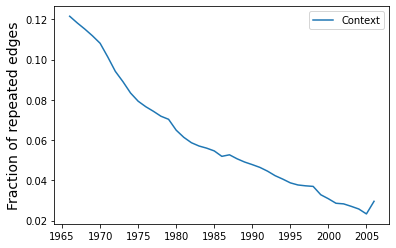

In [ ]:
plt.plot(df["time"], df["frac_repeated"], label="Context");
plt.ylabel("Fraction of repeated edges", fontsize=14);
plt.legend();